In [ ]:
# !pip install seaborn
# !pip install plotly-geo==1.0.0
# !pip install geopandas==0.8.1
# !pip install pyshp==1.2.10
# !pip install shapely==1.6.3
# !pip install -U kaleido

# !pip install plotly

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.request import urlopen
import json

In [2]:
weather_data_directory = "./dataset/WRF-HRRR Dataset"
crop_data_directory = "./dataset/USDA Crop Dataset/data"

### Load Crop Production Data

In [3]:
def load_all_crop_production_data(crop_data_path):
    """
    Load ALL crop production data from all counties, all states, all years
    This will be the master dataset that gets filtered later per zone
    """
    
    crop_types = ['Corn', 'Cotton', 'Soybean', 'WinterWheat']
    years = [2017, 2018, 2019, 2020, 2021, 2022]
    
    all_crop_data = []
    loading_stats = {}
    
    for crop in crop_types:
        crop_records = 0
        for year in years:
            file_path = f"{crop_data_path}/{crop}/{year}"
            try:
                df = pd.read_csv(f"{file_path}/USDA_{crop}_County_{year}.csv")
                df['crop_type'] = crop
                df['year'] = year
                
                all_crop_data.append(df)
                crop_records += len(df)
           
                
            except FileNotFoundError:
                print(f"  {year}: FILE NOT FOUND")
                continue
            except Exception as e:
                print(f"  {year}: ERROR - {e}")
                continue
        
        loading_stats[crop] = crop_records
        print(f"{crop} total: {crop_records:,} records")
    
    if all_crop_data:
        # Combine all data
        master_crop_data = pd.concat(all_crop_data, ignore_index=True)
        return master_crop_data
    
    else:
        print("ERROR: No crop data loaded!")
        return None

In [5]:
all_crop_data = load_all_crop_production_data(crop_data_directory)

Corn total: 8,739 records
Cotton total: 1,901 records
Soybean total: 7,795 records
WinterWheat total: 5,082 records


### Load Weather Data

In [6]:
all_years = [f"{int(year)}" for year in range(2017, 2023, 1)]
all_states = [name for name in os.listdir(os.path.join(weather_data_directory, "2017"))] 

In [7]:
def generate_month_number_string(month_number):
  return f"0{month_number}" if month_number < 10 else f"{month_number}"

def retrieve_weather_data(month = "04", year="2017", type="Monthly"):
  year_dir = os.path.join(weather_data_directory, year)
  file_template = "{}-{}.csv"
  targeted_month = file_template.format(year, month)

  all_data = []
  for state_dir in os.listdir(year_dir):
      state_path = os.path.join(year_dir, state_dir)

       # iteratore over the files in the dir
      for file in os.listdir(state_path):
        if file.endswith(targeted_month):
          # full path to file
          file_path = os.path.join(state_path, file)
          df = pd.read_csv(file_path)

          # only consifer the monthly data for visualization
          df = df[df["Daily/Monthly"] == type]
          # hanlde the fips code
          df["FIPS Code"] = df["FIPS Code"].astype(str).str.zfill(5)
          all_data.append(df)

  # concatenate all dfs into a single one
  monthly_weather_data = pd.concat(all_data)
  return monthly_weather_data

In [8]:
def load_monthly_weather_data(year="2017", months=[month for month in range(1, 13, 1)]):
    monthly_weather = {}
    for month in months:
        month_string = generate_month_number_string(month)
        
        weather = retrieve_weather_data(month=month_string, year=f"{year}")
        monthly_weather[month_string] = weather

    return monthly_weather

def load_daily_weather_data(year="2017"):
    monthly_weather = {}
    for month in range(1, 13, 1):
        month_string = generate_month_number_string(month)
        
        weather = retrieve_weather_data(month=month_string, year=f"{year}", type="Daily")
        monthly_weather[month_string] = weather

    return monthly_weather

In [9]:
growing_season_months = [month for month in range (3, 11, 1)]
growing_season_monthly_2017_weather_data = load_monthly_weather_data(year="2017", months=growing_season_months)


In [10]:
growing_season_monthly_2018_weather_data = load_monthly_weather_data(year="2018", months=growing_season_months)

In [12]:
growing_season_monthly_2019_weather_data = load_monthly_weather_data(year="2019", months=growing_season_months)

In [13]:
growing_season_monthly_2020_weather_data = load_monthly_weather_data(year="2020", months=growing_season_months)

In [14]:
growing_season_monthly_2021_weather_data = load_monthly_weather_data(year="2021", months=growing_season_months)

In [15]:
growing_season_monthly_2022_weather_data = load_monthly_weather_data(year="2022", months=growing_season_months)

In [16]:
def join_all_year_monthly_average_data(yearly_data = []):
    all_years_dataframe = []
    
    for year in yearly_data:
        for _, weather_data in year.items():
            all_years_dataframe.append(weather_data)
    
    return pd.concat(all_years_dataframe, ignore_index=True)

In [17]:
all_years_growing_season_weather_data = join_all_year_monthly_average_data(
    yearly_data=[
        growing_season_monthly_2017_weather_data,
        growing_season_monthly_2018_weather_data,
        growing_season_monthly_2019_weather_data,
        growing_season_monthly_2020_weather_data,
        growing_season_monthly_2021_weather_data,
        growing_season_monthly_2022_weather_data,
    ]
)

In [18]:
all_years_growing_season_weather_data

,Year,Month,Day,Daily/Monthly,State,County,FIPS Code,Grid Index,Lat (llcrnr),Lon (llcrnr),...,Max Temperature (K),Min Temperature (K),Precipitation (kg m**-2),Relative Humidity (%),Wind Gust (m s**-1),Wind Speed (m s**-1),U Component of Wind (m s**-1),V Component of Wind (m s**-1),Downward Shortwave Radiation Flux (W m**-2),Vapor Pressure Deficit (kPa)
0,2017,3,NaN,Monthly,ALABAMA,AUTAUGA,01001,NaN,NaN,NaN,...,295.164146,283.309127,3.182280,63.633333,5.690419,5.171030,-0.175970,0.363411,3709.567527,0.715576
1,2017,3,NaN,Monthly,ALABAMA,BALDWIN,01003,NaN,NaN,NaN,...,295.620186,285.691452,2.377797,73.806029,5.850966,6.956325,-1.043729,0.938347,4129.431623,0.552383
2,2017,3,NaN,Monthly,ALABAMA,BARBOUR,01005,NaN,NaN,NaN,...,296.106185,283.173966,2.019771,61.424946,5.428988,4.927531,0.127199,0.153190,4435.011183,0.807029
3,2017,3,NaN,Monthly,ALABAMA,BIBB,01007,NaN,NaN,NaN,...,294.358833,283.194859,5.117413,66.537097,5.643290,4.529546,-0.193216,0.627343,3770.123992,0.644605
4,2017,3,NaN,Monthly,ALABAMA,BLOUNT,01009,NaN,NaN,NaN,...,292.859567,281.266122,3.363697,66.496313,6.120636,3.382172,0.173418,0.429359,3978.872005,0.583029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143419,2022,10,NaN,Monthly,WYOMING,SWEETWATER,56037,NaN,NaN,NaN,...,287.719521,273.355487,0.134981,48.315833,5.873753,3.426376,1.763406,-0.040385,4158.166195,0.611400
143420,2022,10,NaN,Monthly,WYOMING,TETON,56039,NaN,NaN,NaN,...,282.181556,270.786657,1.223963,56.478436,5.170443,2.363697,1.310704,-0.133107,3682.979687,0.406386
143421,2022,10,NaN,Monthly,WYOMING,UINTA,56041,NaN,NaN,NaN,...,287.492141,274.029530,0.249082,42.671359,5.637654,3.496231,1.899013,-0.142591,4292.671799,0.691226
143422,2022,10,NaN,Monthly,WYOMING,WASHAKIE,56043,NaN,NaN,NaN,...,288.414658,275.818837,0.614827,49.746937,4.113037,2.309229,0.942390,-0.162621,3636.053715,0.635237


In [19]:
yearly_average_growing_season_each_state = all_years_growing_season_weather_data.groupby(["Year", "State"]).agg({
    'Avg Temperature (K)': 'mean',
    'Precipitation (kg m**-2)': 'mean'
})

In [20]:
final_climate_profile = yearly_average_growing_season_each_state.groupby("State").agg({
    'Avg Temperature (K)': 'mean',
    'Precipitation (kg m**-2)': 'mean'
})

In [36]:
state_abbrev = {
   'ALABAMA': 'AL', 'ALASKA': 'AK', 'ARIZONA': 'AZ', 'ARKANSAS': 'AR', 'CALIFORNIA': 'CA',
   'COLORADO': 'CO', 'CONNECTICUT': 'CT', 'DELAWARE': 'DE', 'FLORIDA': 'FL', 'GEORGIA': 'GA',
   'HAWAII': 'HI', 'IDAHO': 'ID', 'ILLINOIS': 'IL', 'INDIANA': 'IN', 'IOWA': 'IA',
   'KANSAS': 'KS', 'KENTUCKY': 'KY', 'LOUISIANA': 'LA', 'MAINE': 'ME', 'MARYLAND': 'MD',
   'MASSACHUSETTS': 'MA', 'MICHIGAN': 'MI', 'MINNESOTA': 'MN', 'MISSISSIPPI': 'MS', 'MISSOURI': 'MO',
   'MONTANA': 'MT', 'NEBRASKA': 'NE', 'NEVADA': 'NV', 'NEW HAMPSHIRE': 'NH', 'NEW JERSEY': 'NJ',
   'NEW MEXICO': 'NM', 'NEW YORK': 'NY', 'NORTH CAROLINA': 'NC', 'NORTH DAKOTA': 'ND', 'OHIO': 'OH',
   'OKLAHOMA': 'OK', 'OREGON': 'OR', 'PENNSYLVANIA': 'PA', 'RHODE ISLAND': 'RI', 'SOUTH CAROLINA': 'SC',
   'SOUTH DAKOTA': 'SD', 'TENNESSEE': 'TN', 'TEXAS': 'TX', 'UTAH': 'UT', 'VERMONT': 'VT',
   'VIRGINIA': 'VA', 'WASHINGTON': 'WA', 'WEST VIRGINIA': 'WV', 'WISCONSIN': 'WI', 'WYOMING': 'WY',
   'DISTRICT OF COLUMBIA': 'DC'
}

clusters = {
  'Hot & Dry': ['ARIZONA', 'TEXAS'],
  'Arid': ['NEW MEXICO', 'CALIFORNIA', 'NEVADA', 'UTAH'],
  'Cold': ['SOUTH DAKOTA', 'MINNESOTA', 'WISCONSIN', 'MICHIGAN', 'VERMONT', 'MAINE', 'NEW HAMPSHIRE', 'NEW YORK'],
  'Continental': ['OREGON', 'WASHINGTON', 'IDAHO', 'COLORADO', 'WYOMING', 'MONTANA', 'NORTH DAKOTA'],
  'Hot & Wet': ['FLORIDA', 'LOUISIANA', 'MISSISSIPPI', 'ALABAMA', 'GEORGIA', 'SOUTH CAROLINA', 'ARKANSAS'],
  'Temperate': ['IOWA', 'ILLINOIS', 'INDIANA', 'MISSOURI', 'OHIO', 'NEBRASKA', 'KANSAS', 'PENNSYLVANIA', 'WEST VIRGINIA', 'VIRGINIA', 'KENTUCKY', 'DELAWARE', 'MARYLAND', 'NEW JERSEY', 'CONNECTICUT', 'RHODE ISLAND', 'MASSACHUSETTS', 'DISTRICT OF COLUMBIA', 'NORTH CAROLINA', 'TENNESSEE', 'OKLAHOMA']
}

colors = {
   'Hot & Dry': '#000000',        # Black
   'Arid': '#E69F00',              # Orange
   'Cold': '#009E73',               # Bluish Green
   'Continental': '#F0E442',        # Yellow
   'Hot & Wet': '#0072B2',       # Blue
   'Temperate': '#8B4513'           # Saddle Brown
}

state_crop_diversity = all_crop_data.groupby('state_name')['commodity_desc'].nunique()


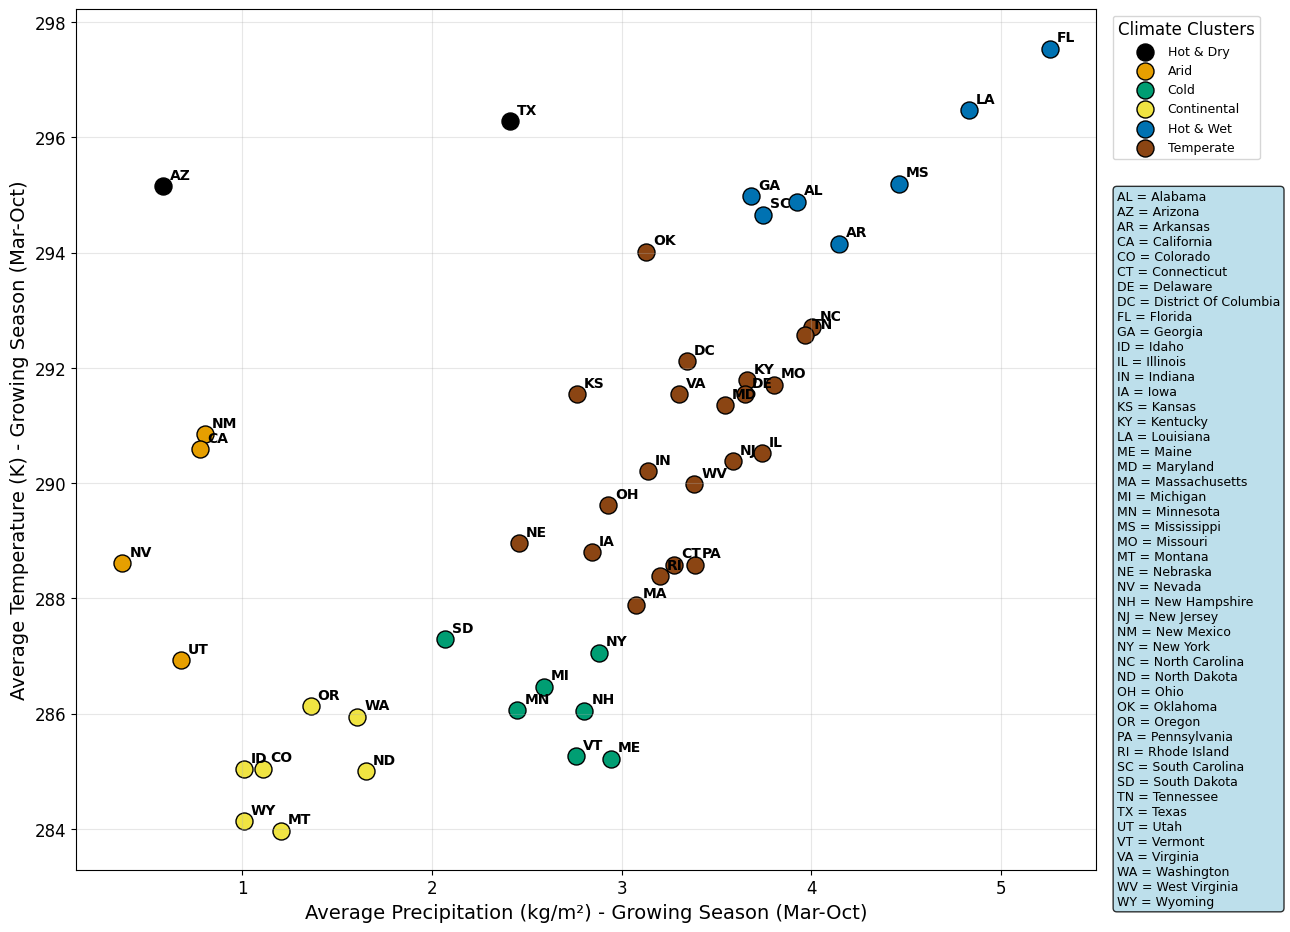

In [37]:
x = final_climate_profile['Precipitation (kg m**-2)']
y = final_climate_profile['Avg Temperature (K)']

plt.figure(figsize=(13, 10))

# Plot each cluster with different colors
for cluster, cluster_states in clusters.items():
   cluster_x = []
   cluster_y = []
   for state in cluster_states:
       if state in final_climate_profile.index:
           cluster_x.append(final_climate_profile.loc[state, 'Precipitation (kg m**-2)'])
           cluster_y.append(final_climate_profile.loc[state, 'Avg Temperature (K)'])
   
   plt.scatter(cluster_x, cluster_y, 
              color=colors[cluster], 
              label=cluster, 
              alpha=1, 
              s=150, 
              edgecolors='black', 
              linewidth=1)

# Add state abbreviation labels
for state in final_climate_profile.index:
   abbrev = state_abbrev.get(state, state[:2])
   plt.annotate(abbrev, 
               (final_climate_profile.loc[state, 'Precipitation (kg m**-2)'],
                final_climate_profile.loc[state, 'Avg Temperature (K)']),
               xytext=(5, 5), 
               textcoords='offset points', 
               fontsize=10,
               ha='left',
               fontweight='bold')

plt.xlabel('Average Precipitation (kg/m²) - Growing Season (Mar-Oct)', fontsize=14)
plt.ylabel('Average Temperature (K) - Growing Season (Mar-Oct)', fontsize=14)
# plt.title('Climate Diversity Across U.S. States\nGrowing Season Averages (2017-2022)', fontsize=16, pad=20)
plt.grid(True, alpha=0.3)

# Increase tick label sizes
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add cluster legend on the right
plt.legend(bbox_to_anchor=(1.01, 1.0), loc='upper left', fontsize=9, 
         title='Climate Clusters', title_fontsize=12, 
         frameon=True, fancybox=True)

# Create state abbreviation legend
legend_states = sorted(final_climate_profile.index)
legend_text1 = '\n'.join([f"{state_abbrev.get(state, state[:2])} = {state.title()}" for state in legend_states])


# Add text boxes in organized columns
props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8)

plt.text(1.02, 0.79, legend_text1, transform=plt.gca().transAxes, fontsize=9,
        verticalalignment='top', bbox=props)



plt.tight_layout()
plt.savefig('climate_diversity_plot.png', dpi=300, bbox_inches='tight', 
           facecolor='white', edgecolor='none')
plt.show()

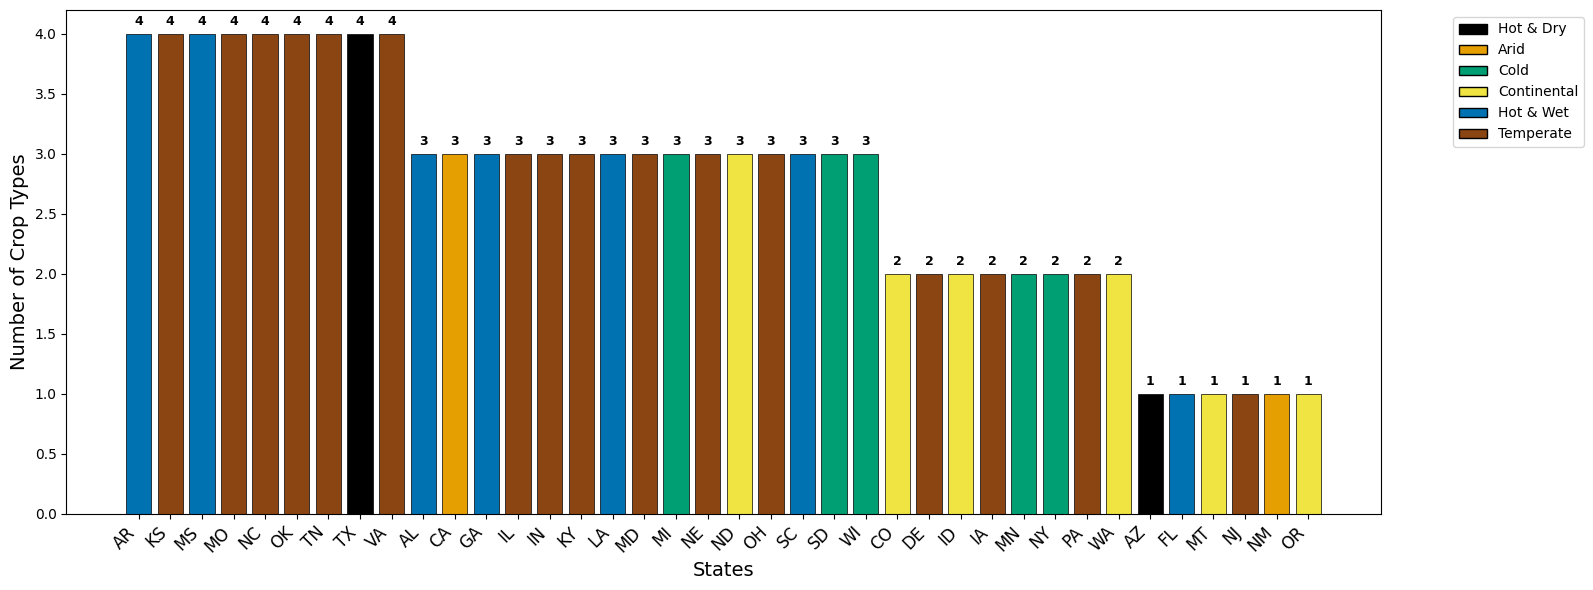

In [38]:
state_crop_diversity = all_crop_data.groupby('state_name')['commodity_desc'].nunique()
crop_div_df = pd.DataFrame({
   'state_name': state_crop_diversity.index,
   'crop_count': state_crop_diversity.values
})

# Add climate cluster information
crop_div_df['climate_cluster'] = crop_div_df['state_name'].map(
   {state: cluster for cluster, states in clusters.items() for state in states}
)

# Sort by crop count (descending) then by state name
crop_div_df = crop_div_df.sort_values(['crop_count', 'state_name'], ascending=[False, True])

# Create visualization
plt.figure(figsize=(16, 6))


# Create bar chart
bars = plt.bar(range(len(crop_div_df)), 
              crop_div_df['crop_count'],
              color=[colors.get(cluster, 'gray') for cluster in crop_div_df['climate_cluster']],
              alpha=1,
              edgecolor='black',
              linewidth=0.5)

# Add state labels
plt.xticks(range(len(crop_div_df)), 
          [state_abbrev.get(state, state[:2]) for state in crop_div_df['state_name']], 
          rotation=45, ha='right', fontsize=12)

plt.ylabel('Number of Crop Types', fontsize=14)
plt.xlabel('States', fontsize=14)
# plt.title('Crop Diversity by State and Climate Cluster', fontsize=16, pad=20)

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, crop_div_df['crop_count'])):
   plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add legend
legend_elements = [plt.Rectangle((0,0),1,1, facecolor=color, alpha=1, edgecolor='black') 
                  for color in colors.values()]
plt.legend(legend_elements, colors.keys(), 
          bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('crop_diversity_each_cluster.png', dpi=300, bbox_inches='tight', 
           facecolor='white', edgecolor='none')
plt.show()


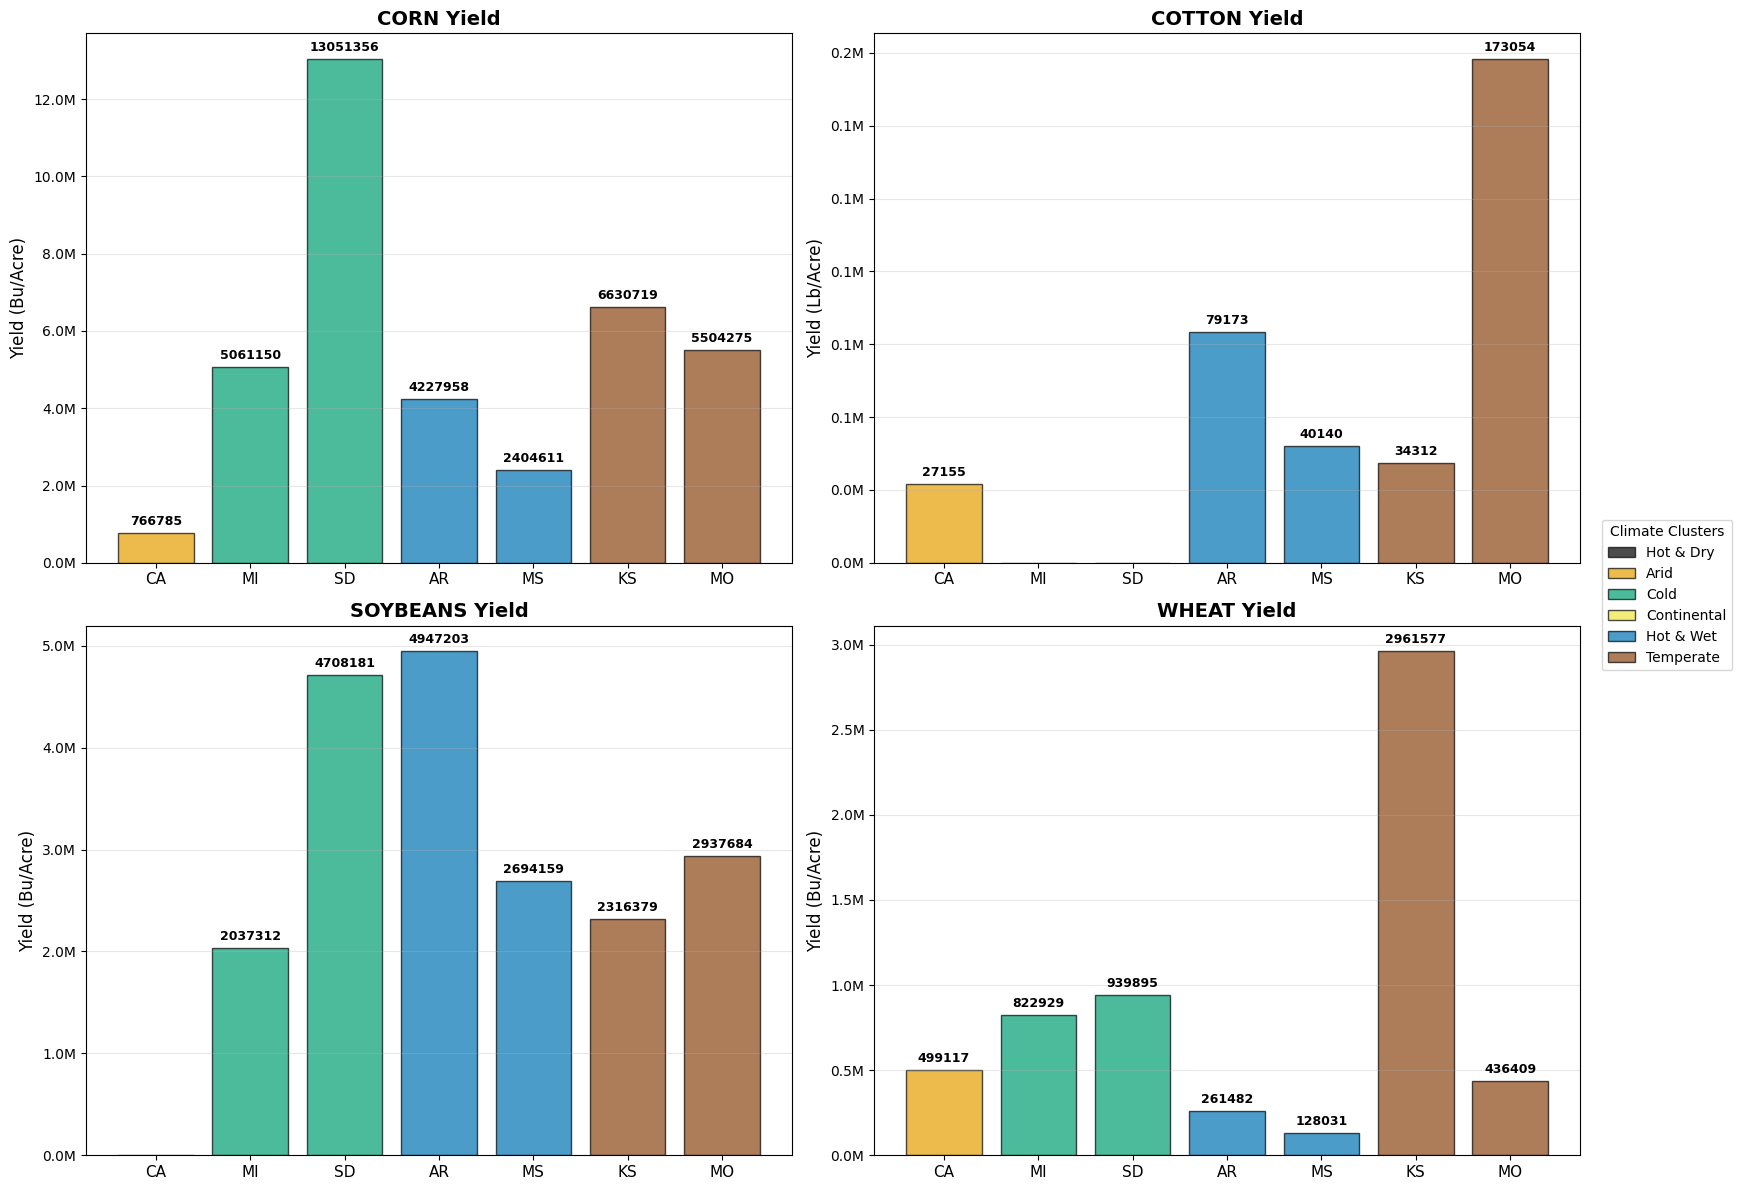

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter data for our 2 selected states
selected_states = ['ARKANSAS', 'MISSISSIPPI', "KANSAS", "MISSOURI", "MICHIGAN", "SOUTH DAKOTA", "CALIFORNIA"]
yield_data = all_crop_data[all_crop_data['state_name'].isin(selected_states)].copy()

# Handle different yield columns for cotton vs other crops
def get_yield_value(row):
   if row['commodity_desc'] == 'COTTON':
       return row['PRODUCTION, MEASURED IN 480 LB BALES']
   else:
       return row['PRODUCTION, MEASURED IN BU']

# Apply the function to get standardized yield values
yield_data['yield_value'] = yield_data.apply(get_yield_value, axis=1)

# Calculate average annual yield by state and crop (2017-2022)
avg_yield = yield_data.groupby(['state_name', 'commodity_desc'])['yield_value'].mean().reset_index()

# Create pivot table for visualization
yield_pivot = avg_yield.pivot(index='state_name', columns='commodity_desc', values='yield_value')
yield_pivot = yield_pivot.fillna(0)  # Fill missing crops with 0

# Assuming clusters, colors, and state_abbrev are already defined

def get_cluster_sort_key(state):
    cluster = get_state_cluster(state)
    cluster_order = ['Hot & Dry', 'Arid', 'Cold', 'Continental', 'Hot & Wet', 'Temperate']
    if cluster in cluster_order:
        return cluster_order.index(cluster)
    return 999  # Put unassigned states at the end

# Sort the pivot table by cluster
yield_pivot = yield_pivot.reindex(sorted(yield_pivot.index, key=get_cluster_sort_key))


# Function to get cluster for a state
def get_state_cluster(state):
    for cluster, states in clusters.items():
        if state in states:
            return cluster
    return None

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# fig.suptitle('Average Annual Yield by State and Crop Type (2017-2022)\nColored by Climate Cluster', fontsize=16, fontweight='bold')

crops = yield_pivot.columns

for i, crop in enumerate(crops):
    ax = axes[i//2, i%2]
    
    # Create bar chart for this crop
    states = yield_pivot.index
    values = yield_pivot[crop]
    
    # Get colors for each state based on their cluster
    bar_colors = []
    for state in states:
        cluster = get_state_cluster(state)
        if cluster:
            bar_colors.append(colors[cluster])
        else:
            bar_colors.append('#808080')  # Gray for unassigned states
    
    bars = ax.bar(range(len(states)), values, color=bar_colors, alpha=0.7, edgecolor='black')
    
    # Add value labels on bars
    for j, (bar, value) in enumerate(zip(bars, values)):
        if value > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
                   f'{value:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Set title and labels with appropriate units
    unit = 'Lb/Acre' if crop == 'COTTON' else 'Bu/Acre'
    ax.set_title(f'{crop} Yield', fontsize=14, fontweight='bold')
    ax.set_ylabel(f'Yield ({unit})', fontsize=12)
    ax.set_xticks(range(len(states)))
    ax.set_xticklabels([state_abbrev.get(state, state[:2]) for state in states], fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

# Add legend for climate clusters
legend_elements = []
for cluster, color in colors.items():
    legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=color, alpha=0.7, edgecolor='black', label=cluster))

# Place legend outside the plot area
fig.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), title='Climate Clusters')

plt.tight_layout()
plt.savefig('crop_productivity_comparison_each_cluster.png', dpi=300, bbox_inches='tight', 
           facecolor='white', edgecolor='none')
plt.show()

In [48]:
# Get yield data for ALL states, not just our 6
def get_yield_value(row):
   if row['commodity_desc'] == 'COTTON':
       return row['YIELD, MEASURED IN LB / ACRE']
   else:
       return row['YIELD, MEASURED IN BU / ACRE']

# Apply the function to get standardized yield values
all_crop_data["yield_value"] = all_crop_data.apply(get_yield_value, axis=1)
all_states_yield = all_crop_data.groupby(['state_name', 'commodity_desc'])['yield_value'].mean().reset_index()
all_yield_pivot = all_states_yield.pivot(index='state_name', columns='commodity_desc', values='yield_value')
all_yield_pivot = all_yield_pivot.fillna(0)

# Calculate crop diversity score for each state
crop_diversity_all = (all_yield_pivot > 0).sum(axis=1)

# Find top performers for each number of crops
print("Top yield performers by crop diversity:")
for num_crops in [4, 3, 2]:
    states_with_n_crops = crop_diversity_all[crop_diversity_all == num_crops].index
    if len(states_with_n_crops) > 0:
        # Calculate average yield across crops they produce
        avg_yields = []
        for state in states_with_n_crops:
            crops_grown = all_yield_pivot.loc[state][all_yield_pivot.loc[state] > 0]
            avg_yield = crops_grown.mean()
            avg_yields.append((state, avg_yield))
        
        # Sort by average yield
        avg_yields.sort(key=lambda x: x[1], reverse=True)
        print(f"\n{num_crops} crops - Top 5 by average yield:")
        for state, yield_val in avg_yields[:5]:
            print(f"  {state}: {yield_val:.1f}")

Top yield performers by crop diversity:

4 crops - Top 5 by average yield:
  MISSOURI: 364.0
  ARKANSAS: 362.1
  TENNESSEE: 332.5
  MISSISSIPPI: 329.1
  VIRGINIA: 304.1

3 crops - Top 5 by average yield:
  CALIFORNIA: 659.6
  LOUISIANA: 393.4
  GEORGIA: 360.4
  ALABAMA: 353.6
  SOUTH CAROLINA: 335.4

2 crops - Top 5 by average yield:
  IDAHO: 154.6
  WASHINGTON: 141.9
  IOWA: 124.7
  MINNESOTA: 111.5
  DELAWARE: 106.8
